# gz/ROS log parsers: LaserScan, Image, PointCloudPacked

Parses gz "echo"-style text logs (like lidar_test.log) and plots time-series summaries.

In [6]:
import os, re, math, json
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- LaserScan: robust parser + visualization helpers ---

from dataclasses import dataclass

@dataclass
class LaserScanParseResult:
    stats: pd.DataFrame               # per-scan stats
    ranges_mat: np.ndarray            # shape: (n_scans, n_beams) with NaN for missing, inf preserved
    finite_mask: np.ndarray           # boolean mask same shape as ranges_mat

def _to_float(s: str) -> float:
    s = s.strip()
    if s.lower() in ("inf", "+inf"):
        return math.inf
    if s.lower() in ("-inf"):
        return -math.inf
    if s.lower() in ("nan", "+nan", "-nan"):
        return math.nan
    try:
        return float(s)
    except Exception:
        return math.nan

def parse_laserscan_log_full(path: str) -> LaserScanParseResult:
    """
    Robust LaserScan parser:
    - Starts a new scan on 'header {' OR when 'count' ranges have been collected.
    - Preserves per-scan ranges (matrix) to enable beam-index visualizations.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    p_header = re.compile(r"^\s*header\s*\{")
    p_frame = re.compile(r'^\s*frame:\s*"([^"]*)"')
    p_kv_f = {
        "angle_min": re.compile(r"^\s*angle_min:\s*([-+A-Za-z0-9\._]+)"),
        "angle_max": re.compile(r"^\s*angle_max:\s*([-+A-Za-z0-9\._]+)"),
        "angle_step": re.compile(r"^\s*angle_step:\s*([-+A-Za-z0-9\._]+)"),
        "range_min": re.compile(r"^\s*range_min:\s*([-+A-Za-z0-9\._]+)"),
        "range_max": re.compile(r"^\s*range_max:\s*([-+A-Za-z0-9\._]+)"),
        "vertical_angle_step": re.compile(r"^\s*vertical_angle_step:\s*([-+A-Za-z0-9\._]+)"),
    }
    p_kv_i = {
        "count": re.compile(r"^\s*count:\s*([0-9]+)"),
        "vertical_count": re.compile(r"^\s*vertical_count:\s*([0-9]+)"),
    }
    p_range = re.compile(r"^\s*ranges:\s*([-+A-Za-z0-9\._]+)")
    p_intensity = re.compile(r"^\s*intensities:\s*([-+A-Za-z0-9\._]+)")  # ignored here

    out_stats: List[Dict[str, Any]] = []
    scans: List[np.ndarray] = []

    cur: Dict[str, Any] = {}
    ranges_buf: List[float] = []

    def finalize():
        nonlocal cur, ranges_buf
        if not ranges_buf and not cur:
            return
        # Decide beam count for this scan
        beam_count = int(cur.get("count") or len(ranges_buf) or 0)
        arr = np.array(ranges_buf, dtype=float)
        # Pad/truncate to declared count to keep a rectangular matrix later
        if beam_count > 0:
            if arr.size < beam_count:
                arr = np.pad(arr, (0, beam_count - arr.size), constant_values=np.nan)
            elif arr.size > beam_count:
                arr = arr[:beam_count]
        else:
            # No declared count, just use current length
            beam_count = arr.size
        # Stats on finite values
        finite = np.isfinite(arr)
        finite_vals = arr[finite]
        stats = {
            "finite_ratio": float(finite_vals.size / beam_count) if beam_count else np.nan,
            "mean_range": float(np.mean(finite_vals)) if finite_vals.size else np.nan,
            "min_range": float(np.min(finite_vals)) if finite_vals.size else np.nan,
            "max_range": float(np.max(finite_vals)) if finite_vals.size else np.nan,
            "count": int(cur.get("count") or beam_count),
            "frame": cur.get("frame"),
            "angle_min": cur.get("angle_min"),
            "angle_max": cur.get("angle_max"),
            "angle_step": cur.get("angle_step"),
            "range_min": cur.get("range_min"),
            "range_max": cur.get("range_max"),
            "vertical_count": cur.get("vertical_count"),
        }
        out_stats.append(stats)
        scans.append(arr)
        # Reset for next scan (keep static fields only if we truly lack new headers)
        # Here we reset everything and will re-capture fields as they appear.
        cur = {}
        ranges_buf = []

    with open(path, "r") as f:
        for line in f:
            if p_header.search(line):
                # New message begins
                finalize()
                cur = {}
                ranges_buf = []
                continue

            m = p_frame.search(line)
            if m:
                cur["frame"] = m.group(1)
                continue

            matched = False
            for k, pat in p_kv_f.items():
                mm = pat.search(line)
                if mm:
                    cur[k] = _to_float(mm.group(1))
                    matched = True
                    break
            if matched:
                continue

            for k, pat in p_kv_i.items():
                mm = pat.search(line)
                if mm:
                    try:
                        cur[k] = int(mm.group(1))
                    except Exception:
                        cur[k] = None
                    matched = True
                    break
            if matched:
                continue

            mr = p_range.search(line)
            if mr:
                ranges_buf.append(_to_float(mr.group(1)))
                # If we know 'count', finalize when we have that many ranges
                if cur.get("count") and len(ranges_buf) >= int(cur["count"]):
                    finalize()
                continue

            if p_intensity.search(line):
                # Optional: could store intensities if needed
                continue

    # finalize trailing scan
    finalize()

    if not out_stats or not scans:
        raise RuntimeError("No LaserScan messages parsed from log")

    # Build rectangular matrix (pad to the maximum beam count across scans)
    max_beams = max(arr.size for arr in scans)
    mat = np.full((len(scans), max_beams), np.nan, dtype=float)
    for i, arr in enumerate(scans):
        mat[i, :arr.size] = arr

    df = pd.DataFrame(out_stats)
    df.insert(0, "t", np.arange(len(df)))
    finite_mask = np.isfinite(mat)
    return LaserScanParseResult(stats=df, ranges_mat=mat, finite_mask=finite_mask)


def _contiguous_spans(indices: np.ndarray) -> List[Tuple[int, int]]:
    """Turn sorted indices into [start, end] inclusive spans."""
    if indices.size == 0:
        return []
    spans = []
    s = int(indices[0])
    prev = s
    for v in indices[1:]:
        v = int(v)
        if v == prev + 1:
            prev = v
        else:
            spans.append((s, prev))
            s = prev = v
    spans.append((s, prev))
    return spans


def plot_laserscan_overview(result: LaserScanParseResult, title: str = "LaserScan overview"):
    df = result.stats
    mat = result.ranges_mat
    finite_mask = result.finite_mask

    if df.empty or mat.size == 0:
        print("Empty result")
        return

    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    gs = fig.add_gridspec(3, 2)

    # 1) Finite ratio over time
    ax = fig.add_subplot(gs[0, :])
    ax.plot(df["t"], df["finite_ratio"], color="tab:purple", lw=1.5)
    ax.set_ylabel("finite ratio")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)

    # 2) Binary mask heatmap (beam index vs scan index)
    ax = fig.add_subplot(gs[1, :])
    im = ax.imshow(finite_mask, aspect="auto", origin="lower", interpolation="nearest", cmap="Greys")
    ax.set_xlabel("beam index")
    ax.set_ylabel("scan index (t)")
    ax.set_title("Finite returns mask (white=True)")
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

    # 3) Overlay sample scan profiles (range vs beam index)
    ax = fig.add_subplot(gs[2, 0])
    n_scans = mat.shape[0]
    stride = max(1, n_scans // 20)
    for i in range(0, n_scans, stride):
        y = mat[i]
        ax.plot(np.arange(y.size), y, lw=0.8, alpha=0.4)
    ax.set_xlabel("beam index")
    ax.set_ylabel("range [m]")
    ax.set_title("Sampled scan profiles")
    ax.grid(True, alpha=0.3)

    # 4) Count of finite beams per scan (peaks indicator)
    ax = fig.add_subplot(gs[2, 1])
    finite_counts = finite_mask.sum(axis=1)
    ax.plot(np.arange(n_scans), finite_counts, color="tab:blue", lw=1.2)
    ax.set_xlabel("scan index (t)")
    ax.set_ylabel("# finite beams")
    ax.set_title("Finite beams per scan")
    ax.grid(True, alpha=0.3)

    plt.show()

    # Print stable obstacle columns (present in most scans)
    frac = finite_mask.mean(axis=0)  # fraction of scans with finite return at each beam
    stable_cols = np.where(frac > 0.6)[0]  # adjustable threshold
    spans = _contiguous_spans(stable_cols)
    if spans:
        print("Stable obstacle beam-index spans (appearing in >60% scans):")
        for a, b in spans:
            print(f"  {a}–{b} (width {b - a + 1})")
    else:
        print("No stable beam spans above threshold found.")

def _finalize_laserscan_block(cur: Dict[str, Any], out: List[Dict[str, Any]]):
    if not cur:
        return
    ranges = cur.get("ranges", [])
    rngs = np.array(ranges, dtype=float) if ranges else np.array([], dtype=float)
    finite = np.isfinite(rngs)
    finite_vals = rngs[finite]
    stats = {
        "finite_ratio": float(finite_vals.size / rngs.size) if rngs.size else np.nan,
        "mean_range": float(np.mean(finite_vals)) if finite_vals.size else np.nan,
        "min_range": float(np.min(finite_vals)) if finite_vals.size else np.nan,
        "max_range": float(np.max(finite_vals)) if finite_vals.size else np.nan,
        "count": int(cur.get("count") or rngs.size),
        "frame": cur.get("frame"),
        "angle_min": cur.get("angle_min"),
        "angle_max": cur.get("angle_max"),
        "angle_step": cur.get("angle_step"),
        "range_min": cur.get("range_min"),
        "range_max": cur.get("range_max"),
        "vertical_count": cur.get("vertical_count"),
    }
    out.append(stats)

def parse_laserscan_log(path: str) -> pd.DataFrame:
    """Parse gz/ROS echo text for gz::msgs::LaserScan style blocks.
    Returns a DataFrame with per-message summary stats.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    # Patterns
    p_header = re.compile(r"^\s*header\s*\{")
    p_frame = re.compile(r"^\s*frame:\s*\"([^\"]*)\"")
    p_kv_f = {
        "angle_min": re.compile(r"^\s*angle_min:\s*([-+A-Za-z0-9\._]+)"),
        "angle_max": re.compile(r"^\s*angle_max:\s*([-+A-Za-z0-9\._]+)"),
        "angle_step": re.compile(r"^\s*angle_step:\s*([-+A-Za-z0-9\._]+)"),
        "range_min": re.compile(r"^\s*range_min:\s*([-+A-Za-z0-9\._]+)"),
        "range_max": re.compile(r"^\s*range_max:\s*([-+A-Za-z0-9\._]+)"),
        "vertical_angle_step": re.compile(r"^\s*vertical_angle_step:\s*([-+A-Za-z0-9\._]+)"),
    }
    p_kv_i = {
        "count": re.compile(r"^\s*count:\s*([0-9]+)"),
        "vertical_count": re.compile(r"^\s*vertical_count:\s*([0-9]+)"),
    }
    p_range = re.compile(r"^\s*ranges:\s*([-+A-Za-z0-9\._]+)")

    out: List[Dict[str, Any]] = []
    cur: Dict[str, Any] = {}

    with open(path, 'r') as f:
        for line in f:
            if p_header.search(line):
                # new message begins; finalize previous
                _finalize_laserscan_block(cur, out)
                cur = {"ranges": []}
                continue

            m = p_frame.search(line)
            if m:
                cur["frame"] = m.group(1)
                continue

            # numeric scalar fields
            matched = False
            for k, pat in p_kv_f.items():
                mm = pat.search(line)
                if mm:
                    cur[k] = _to_float(mm.group(1))
                    matched = True
                    break
            if matched:
                continue

            for k, pat in p_kv_i.items():
                mm = pat.search(line)
                if mm:
                    try:
                        cur[k] = int(mm.group(1))
                    except Exception:
                        cur[k] = None
                    matched = True
                    break
            if matched:
                continue

            # ranges
            mr = p_range.search(line)
            if mr:
                cur.setdefault("ranges", []).append(_to_float(mr.group(1)))
                continue

    # finalize last
    _finalize_laserscan_block(cur, out)

    if not out:
        raise RuntimeError("No LaserScan messages parsed from log")

    df = pd.DataFrame(out)
    df.insert(0, "t", np.arange(len(df)))  # synthetic time index
    return df

def parse_image_log_metadata(path: str) -> pd.DataFrame:
    """Parse gz::msgs::Image metadata (width, height, pixel_format).
    Designed for echo-like logs without actual pixel payload parsing.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    p_header = re.compile(r"^\s*header\s*\{")
    p_width = re.compile(r"^\s*width:\s*([0-9]+)")
    p_height = re.compile(r"^\s*height:\s*([0-9]+)")
    p_format = re.compile(r"^\s*pixel_format_type:\s*([A-Za-z0-9_]+)|^\s*pixel_format:\s*([A-Za-z0-9_]+)")
    blocks = []
    cur = {}
    with open(path, 'r') as f:
        for line in f:
            if p_header.search(line):
                if cur:
                    blocks.append(cur)
                cur = {}
                continue
            m = p_width.search(line)
            if m:
                cur["width"] = int(m.group(1))
                continue
            m = p_height.search(line)
            if m:
                cur["height"] = int(m.group(1))
                continue
            m = p_format.search(line)
            if m:
                cur["pixel_format"] = m.group(1) or m.group(2)
                continue
    if cur:
        blocks.append(cur)
    df = pd.DataFrame(blocks)
    if not df.empty:
        df.insert(0, "t", np.arange(len(df)))
        df["num_pixels"] = df.get("width", 0) * df.get("height", 0)
    return df

def parse_pointcloud_packed_metadata(path: str) -> pd.DataFrame:
    """Parse gz::msgs::PointCloudPacked metadata (width, height, point_step).
    Does not decode binary data; yields counts/time index for plotting volume over time.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    p_header = re.compile(r"^\s*header\s*\{")
    p_width = re.compile(r"^\s*width:\s*([0-9]+)")
    p_height = re.compile(r"^\s*height:\s*([0-9]+)")
    p_point_step = re.compile(r"^\s*point_step:\s*([0-9]+)")
    blocks = []
    cur = {}
    with open(path, 'r') as f:
        for line in f:
            if p_header.search(line):
                if cur:
                    blocks.append(cur)
                cur = {}
                continue
            m = p_width.search(line)
            if m:
                cur["width"] = int(m.group(1))
                continue
            m = p_height.search(line)
            if m:
                cur["height"] = int(m.group(1))
                continue
            m = p_point_step.search(line)

            if m:
                cur["point_step"] = int(m.group(1))
                continue
    if cur:
        blocks.append(cur)
    df = pd.DataFrame(blocks)
    if not df.empty:
        df.insert(0, "t", np.arange(len(df)))
        w = df.get("width", 0).fillna(0).astype(int)
        h = df.get("height", 0).fillna(1).astype(int)
        df["num_points"] = (w * h).astype(int)
    return df

In [7]:
def plot_laserscan_timeseries(df: pd.DataFrame, title: str = "LaserScan stats"):
    if df.empty:
        print("Empty DataFrame")
        return
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)

    ax = axes[0]
    ax.plot(df["t"], df["finite_ratio"], color="tab:purple", lw=1.5, label="finite_ratio")
    ax.set_ylabel("finite ratio")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    ax = axes[1]
    ax.plot(df["t"], df["mean_range"], color="tab:blue", lw=1.2, label="mean")
    ax.plot(df["t"], df["min_range"], color="tab:green", lw=1.0, alpha=0.8, label="min")
    ax.plot(df["t"], df["max_range"], color="tab:orange", lw=1.0, alpha=0.8, label="max")
    ax.set_xlabel("message index")
    ax.set_ylabel("range [m]")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.suptitle(title)
    plt.show()

def preview(df: pd.DataFrame, n: int = 5):
    display(df.head(n))
    print(f"rows: {len(df)} columns: {list(df.columns)}")

,t,finite_ratio,mean_range,min_range,max_range,count,frame,angle_min,angle_max,angle_step,range_min,range_max,vertical_count
0,0,0.194444,2.330653,1.594281,4.067769,360,vehicle_blue::lidar_link::gpu_lidar,-3.14159,3.14159,0.017502,0.2,12.0,1
1,1,0.194444,2.316345,1.613089,4.151762,360,vehicle_blue::lidar_link::gpu_lidar,-3.14159,3.14159,0.017502,0.2,12.0,1
2,2,0.194444,2.339399,1.725474,4.165284,360,vehicle_blue::lidar_link::gpu_lidar,-3.14159,3.14159,0.017502,0.2,12.0,1
3,3,0.194444,2.323411,1.605393,4.027012,360,vehicle_blue::lidar_link::gpu_lidar,-3.14159,3.14159,0.017502,0.2,12.0,1
4,4,0.194444,2.317934,1.568613,4.203437,360,vehicle_blue::lidar_link::gpu_lidar,-3.14159,3.14159,0.017502,0.2,12.0,1


rows: 150 columns: ['t', 'finite_ratio', 'mean_range', 'min_range', 'max_range', 'count', 'frame', 'angle_min', 'angle_max', 'angle_step', 'range_min', 'range_max', 'vertical_count']


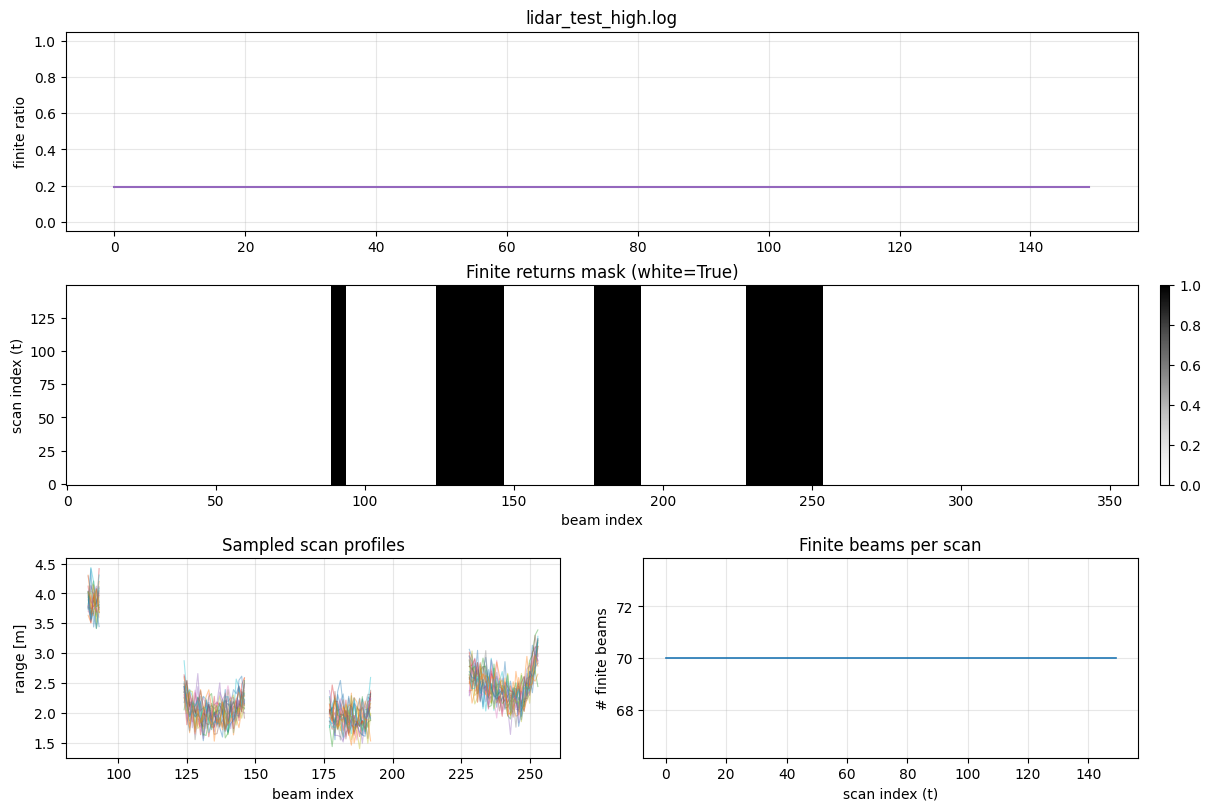

Stable obstacle beam-index spans (appearing in >60% scans):
  89–93 (width 5)
  124–146 (width 23)
  177–192 (width 16)
  228–253 (width 26)
Parsed scans: 150, beams per scan (matrix width): 360


In [10]:
# Example: parse and plot your lidar log
lidar_log = "/workspaces/585_Probabilistic_Robotics/ros2_motion_noise/lidar_test_high.log"
res = parse_laserscan_log_full(lidar_log)
preview(res.stats)
plot_laserscan_overview(res, title=os.path.basename(lidar_log))

print(f"Parsed scans: {len(res.stats)}, beams per scan (matrix width): {res.ranges_mat.shape[1]}")

Notes:
- For RGB and depth camera, pass a similar echo log to `parse_image_log_metadata(path)` to get a time series of width/height for quick checks. If you have saved image files instead of echo output, we can extend this to compute per-frame intensity/depth summaries.
- For depth cloud/point cloud, pass echo logs of `gz::msgs::PointCloudPacked` to `parse_pointcloud_packed_metadata(path)` to get a time series of point counts. If you need per-frame XYZ stats, consider logging to files (e.g., PCD) or reading rosbag2 and decoding binary payloads.